In [1]:
import numpy as np
import time
import warnings

warnings.filterwarnings("ignore", category=np.ComplexWarning)
np.set_printoptions(formatter={'float': '{: .10e}'.format}, linewidth=1000)

## 1. HE Environment Setup

In [2]:
import sys
import importlib
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import engine.HEdata
import engine.HEengine

importlib.reload(engine.HEdata)
importlib.reload(engine.HEengine)

from engine.HEengine import HEengine
from engine.HEdata import Message, Ciphertext

import os

# HE_DEVICE=cpu / HE_SETTING_ROOT=... to run on a HEaaN-CPU environment.
engine = HEengine(
    device_type=os.environ.get("HE_DEVICE", "gpu"),
    setting_root=os.environ.get("HE_SETTING_ROOT", "/root/heaan_setting/"),
)

## 2. Approx invSqrt using Chebyshev Polynomial

In [3]:
def genData(start, middle, end, n):
    a = np.linspace(start, middle, n//2)
    b = np.linspace(middle, end, n//2)
    return np.concatenate((a, b))

In [30]:
def ret_print(x, y, y_eval):
    print("Input\t\t:", x)
    print("Answer\t\t:", y)
    print("Eval ret\t:", y_eval)

    err = y - y_eval
    mre = np.mean(np.abs(err) / np.abs(y))

    print("MRE\t\t:", mre)

--- 63차 체비쇼프 근사 다항식 계수 ---


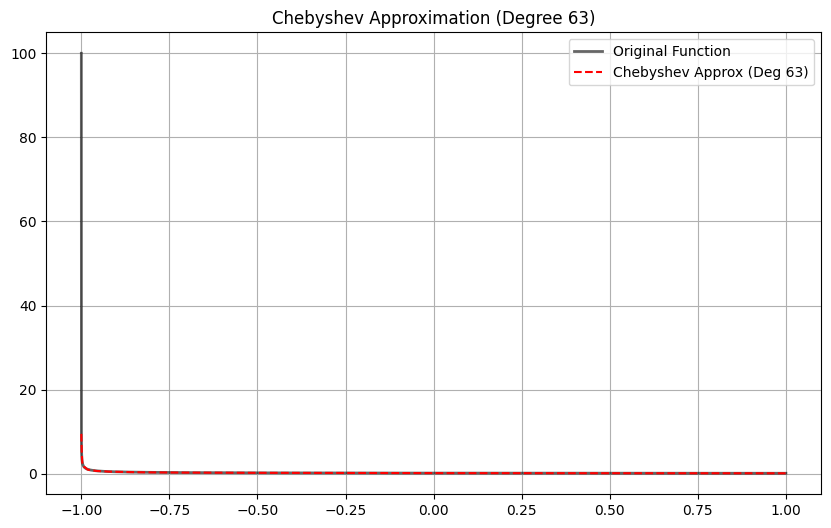


최대 오차 (Max Error): 9.05e-01


(array([-1.0000000000e+00, -9.9999800000e-01, -9.9999600000e-01, ...,  9.9999600000e-01,  9.9999800000e-01,  1.0000000000e+00]),
 array([ 9.9999999998e+01,  7.0710678117e+01,  5.7735026919e+01, ...,  1.0000010000e-01,  1.0000005000e-01,  1.0000000000e-01]),
 array([ 9.4693859487e+00,  9.4597242034e+00,  9.4500724233e+00, ...,  9.9236320438e-02,  9.9229936403e-02,  9.9223535043e-02]),
 array([], dtype=float64))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Chebyshev

def get_chebyshev_approximation(target_func, degree, domain):
    approx_poly = Chebyshev.interpolate(target_func, degree, domain=domain)
    return approx_poly

K = 2 # inverse of K-th root
DOMAIN = [-1, 1]

# 1. 설정
log_deg = 6
degree = 2**log_deg-1

A = 1 * (10 ** -4)
B = 1 * (10 ** 2)

def func(h):
    result = []
    for x in h:
        x = (B-A)*x/2+(B+A)/2
        result.append(pow(x, -1/K))
    return np.array(result)    

# 3. 근사 다항식 생성
cheb_poly = get_chebyshev_approximation(func, degree, DOMAIN)

# 4. 결과 확인 (다항식 계수 출력)
print(f"--- {degree}차 체비쇼프 근사 다항식 계수 ---") 

# 5. 시각화 (원본 vs 근사)
x_vals = np.linspace(DOMAIN[0], DOMAIN[1], 1000000)
y_true = func(x_vals)
y_approx = cheb_poly(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_true, 'k-', label='Original Function', linewidth=2, alpha=0.6)
plt.plot(x_vals, y_approx, 'r--', label=f'Chebyshev Approx (Deg {degree})')

plt.title(f"Chebyshev Approximation (Degree {degree})")
plt.legend()
plt.grid(True)
plt.show()

# 6. 오차 확인
error = np.abs(y_true - y_approx) / y_true
print(f"\n최대 오차 (Max Error): {np.max(error):.2e}")
x_vals, y_true, y_approx, y_approx[y_approx<0]

In [16]:
x = np.concatenate([np.linspace(A, (A+B)/2, 10000000), np.linspace((A+B)/2, B, 10000000)])
y_ans = x**(-1/2)

print(f"X\n{x}\n")

trans_x = x*2/(B-A) - (B+A)/(B-A)
cheb_y = cheb_poly(trans_x)
print("First Approx")
print(cheb_y)
print("#Neg\t\t:", len(cheb_y[cheb_y < 0]))
print()

iter = 10
y_iter = np.copy(cheb_y)

for i in range(iter):
    print("#", i+1)
    y_iter = (3/2) * y_iter - (1/2)*x*(y_iter**3)
    ret_print(x, y_ans, y_iter)
    print("Max RE\t\t:", np.max(np.abs((y_ans-y_iter)/y_ans)), f"({np.argmax(np.abs((y_ans-y_iter)/y_ans))})")
    print()

X
[ 1.0000000000e-04  1.0499999550e-04  1.0999999100e-04 ...  9.9999990000e+01  9.9999995000e+01  1.0000000000e+02]

First Approx
[ 9.4693859487e+00  9.4689026250e+00  9.4684193263e+00 ...  9.9224175959e-02  9.9223855523e-02  9.9223535043e-02]
#Neg		: 0

# 1
Input		: [ 1.0000000000e-04  1.0499999550e-04  1.0999999100e-04 ...  9.9999990000e+01  9.9999995000e+01  1.0000000000e+02]
Answer		: [ 1.0000000000e+02  9.7590009386e+01  9.5346262825e+01 ...  1.0000000500e-01  1.0000000250e-01  1.0000000000e-01]
Eval ret	: [ 1.4161623277e+01  1.4158782336e+01  1.4155942082e+01 ...  9.9990999689e-02  9.9990989816e-02  9.9990979939e-02]
MRE		: 0.0003849325093090112
Max RE		: 0.8583837672338605 (0)

# 2
Input		: [ 1.0000000000e-04  1.0499999550e-04  1.0999999100e-04 ...  9.9999990000e+01  9.9999995000e+01  1.0000000000e+02]
Answer		: [ 1.0000000000e+02  9.7590009386e+01  9.5346262825e+01 ...  1.0000000500e-01  1.0000000250e-01  1.0000000000e-01]
Eval ret	: [ 2.1100428123e+01  2.1089156098e+01  2.1077

In [ ]:
from pathlib import Path

coeff_path = Path("invSqrt_coeffs.py")

try:
    from coeffs.invSqrt_coeffs import _INV_SQRT_COEFFS
    coeffs_dict = dict(_INV_SQRT_COEFFS)
except (ImportError, TypeError, ValueError):
    coeffs_dict = {}

coeffs_dict[degree] = cheb_poly.coef.astype(float).tolist()

lines = ["_INV_SQRT_COEFFS = {"]

for degree in sorted(coeffs_dict):
    coeffs = ", ".join(repr(value) for value in coeffs_dict[degree])
    lines.append(f"    {degree}: [{coeffs}],")

lines.append("}")
lines.append("")

_ = coeff_path.write_text("\n".join(lines), encoding="utf-8")

## 2-1. invSqrt coefficients for normalized input (V / V_max in [V_min, 1])

Coefficients for `HEApprox.invSqrt(..., method="normalized")`.
The input is normalized by the public bound V_max (Welch: V / V_max, F-test: s2^2 / Var2_max), so V_max = 1 and
three V_min candidates are generated for degrees 2^4-1, ..., 2^9-1. Saved to `coeffs/invSqrt_coeffs_normalized.py`.

V_min	degree	MRE(lin)	MaxRE(lin)	MaxRE(geom)	#Neg
1e-03	15	2.64e-02	3.78e-01	3.78e-01	0


1e-03	31	6.55e-03	1.19e-01	1.19e-01	0


1e-03	63	5.81e-04	1.22e-02	1.22e-02	0


1e-03	127	6.93e-06	1.59e-04	1.59e-04	0


1e-03	255	1.46e-09	3.54e-08	3.54e-08	0


...

1e-05	31	1.90e-02	8.51e-01	8.51e-01	0


1e-05	63	9.23e-03	7.10e-01	7.10e-01	0


1e-05	127	3.94e-03	4.71e-01	4.71e-01	0


1e-05	255	1.17e-03	1.89e-01	1.89e-01	0


1e-05	511	1.54e-04	3.00e-02	3.00e-02	0


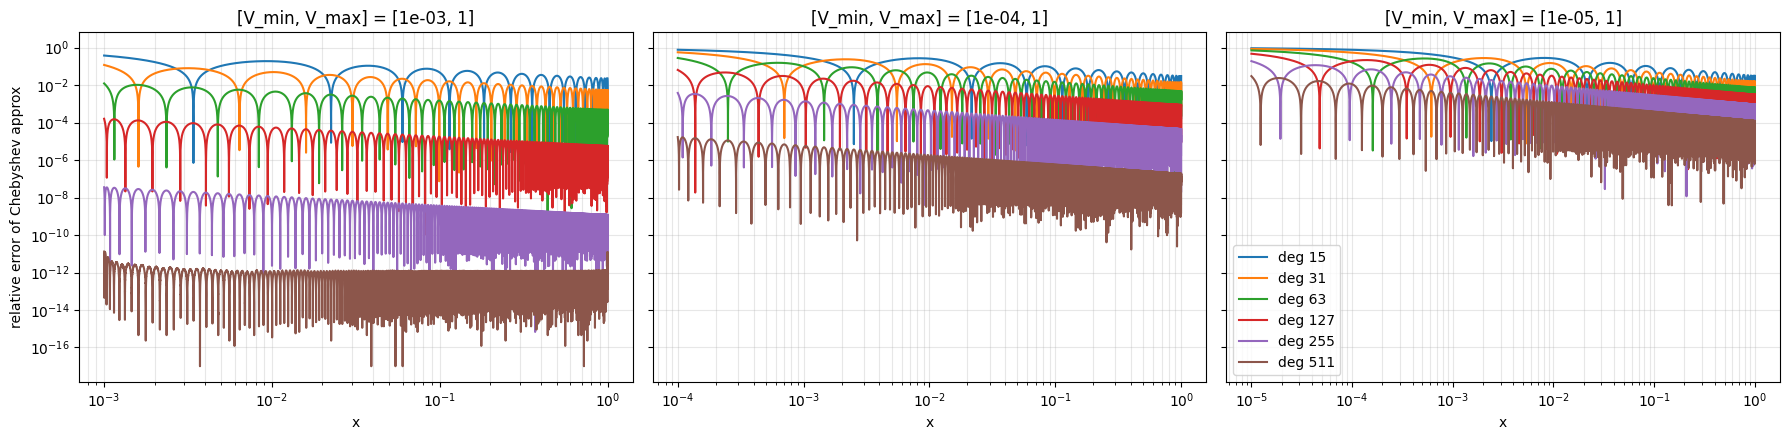

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Chebyshev

NORM_V_MIN_LIST = [1e-3, 1e-4, 1e-5]
NORM_V_MAX = 1.0
NORM_LOG_DEG_LIST = range(4, 10)  # degree = 2^4-1, ..., 2^9-1

def make_inv_sqrt_func(a, b, k=2):
    def func(h):
        x = (b-a)*h/2+(b+a)/2
        return x ** (-1/k)
    return func

def to_cheb(x, a, b):
    return x*2/(b-a) - (b+a)/(b-a)

# norm_cheb_polys[V_min][degree]
norm_cheb_polys = {}

for a in NORM_V_MIN_LIST:
    func = make_inv_sqrt_func(a, NORM_V_MAX)
    norm_cheb_polys[a] = {
        2**ld-1: Chebyshev.interpolate(func, 2**ld-1, domain=[-1, 1])
        for ld in NORM_LOG_DEG_LIST
    }

print("V_min\tdegree\tMRE(lin)\tMaxRE(lin)\tMaxRE(geom)\t#Neg")

for a, polys in norm_cheb_polys.items():
    x_lin = np.linspace(a, NORM_V_MAX, 1000000)
    x_geo = np.geomspace(a, NORM_V_MAX, 1000000)

    for deg, poly in polys.items():
        err_lin = np.abs(poly(to_cheb(x_lin, a, NORM_V_MAX)) * np.sqrt(x_lin) - 1)
        y_geo = poly(to_cheb(x_geo, a, NORM_V_MAX))
        err_geo = np.abs(y_geo * np.sqrt(x_geo) - 1)
        print(f"{a:.0e}\t{deg}\t{np.mean(err_lin):.2e}\t{np.max(err_lin):.2e}\t{np.max(err_geo):.2e}\t{np.sum(y_geo < 0)}")

fig, axes = plt.subplots(1, len(NORM_V_MIN_LIST), figsize=(6*len(NORM_V_MIN_LIST), 4.5), sharey=True)

for ax, a in zip(axes, NORM_V_MIN_LIST):
    x_geo = np.geomspace(a, NORM_V_MAX, 100000)
    for deg, poly in norm_cheb_polys[a].items():
        y = poly(to_cheb(x_geo, a, NORM_V_MAX))
        ax.loglog(x_geo, np.abs(y*np.sqrt(x_geo) - 1) + 1e-17, label=f"deg {deg}")
    ax.set_title(f"[V_min, V_max] = [{a:.0e}, {NORM_V_MAX:g}]")
    ax.set_xlabel("x")
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("relative error of Chebyshev approx")
axes[-1].legend()
plt.tight_layout()
plt.show()

In [5]:
# Plaintext Newton convergence: smallest iteration count with MRE / MaxRE <= 1e-8
# (HE iteration counts are chosen with HE-DAP, experiments/invsqrt/)
print("V_min\tdegree\tMRE(0)\t\tMaxRE(0)\titer(MRE<=1e-8)\titer(MaxRE<=1e-8)")

for a, polys in norm_cheb_polys.items():
    x = genData(a, (a+NORM_V_MAX)/2, NORM_V_MAX, 2**15)
    y_ans = x**(-1/2)

    for deg, poly in polys.items():
        y_iter = poly(to_cheb(x, a, NORM_V_MAX))
        re = np.abs((y_ans-y_iter)/y_ans)
        mre0, maxre0 = np.mean(re), np.max(re)
        it_mre, it_max = None, None

        for i in range(15):
            y_iter = (3/2) * y_iter - (1/2)*x*(y_iter**3)
            re = np.abs((y_ans-y_iter)/y_ans)
            if it_mre is None and np.mean(re) <= 1e-8:
                it_mre = i+1
            if it_max is None and np.max(re) <= 1e-8:
                it_max = i+1

        print(f"{a:.0e}\t{deg}\t{mre0:.2e}\t{maxre0:.2e}\t{it_mre}\t\t{it_max}")

V_min	degree	MRE(0)		MaxRE(0)	iter(MRE<=1e-8)	iter(MaxRE<=1e-8)
1e-03	15	2.64e-02	3.78e-01	4		5
1e-03	31	6.55e-03	1.19e-01	3		4
1e-03	63	5.82e-04	1.22e-02	2		3
1e-03	127	6.93e-06	1.59e-04	1		2
1e-03	255	1.46e-09	3.54e-08	1		1
1e-03	511	7.83e-13	1.31e-11	1		1
1e-04	15	3.61e-02	7.68e-01	7		8
1e-04	31	1.67e-02	5.63e-01	5		6
1e-04	63	5.88e-03	2.79e-01	4		5
1e-04	127	1.09e-03	6.44e-02	2		3
1e-04	255	5.68e-05	3.81e-03	2		2
1e-04	511	2.32e-07	1.69e-05	1		1
1e-05	15	3.74e-02	9.25e-01	10		11
1e-05	31	1.90e-02	8.51e-01	8		9
1e-05	63	9.24e-03	7.10e-01	6		7
1e-05	127	3.95e-03	4.71e-01	5		6
1e-05	255	1.18e-03	1.89e-01	3		4
1e-05	511	1.55e-04	3.00e-02	2		3


In [6]:
from pathlib import Path

# Run from coeffs/ -> coeffs/invSqrt_coeffs_normalized.py
norm_coeff_path = Path("invSqrt_coeffs_normalized.py")

lines = [
    "# Generated by coeffs/approx.ipynb (section 2-1)",
    "# Chebyshev coefficients of 1/sqrt(x) on [V_min, V_MAX], mapped to [-1, 1].",
    f"_INV_SQRT_NORM_V_MAX = {NORM_V_MAX!r}",
    "",
    "_INV_SQRT_NORM_COEFFS = {",
]

for a, polys in norm_cheb_polys.items():
    lines.append(f"    {a!r}: {{")
    for deg, poly in polys.items():
        coeffs = ", ".join(repr(value) for value in poly.coef.astype(float).tolist())
        lines.append(f"        {deg}: [{coeffs}],")
    lines.append("    },")

lines.append("}")
lines.append("")

_ = norm_coeff_path.write_text("\n".join(lines), encoding="utf-8")
print(norm_coeff_path.resolve())

/pp_test/coeffs/invSqrt_coeffs_normalized.py


## 3. Test invSqrt using HEengine

In [19]:
data_num = 100_000
test = genData(A, (A+B)/2, B, data_num)

msg = Message(test, value=B)
msg.to(engine.dt)

ctxt = engine.enc(msg)

x_half = engine.mult(ctxt, 1/2)

x_cheb = engine.mult(ctxt, 2/(B-A))
x_cheb = engine.sub(x_cheb, (B+A)/(B-A))

In [24]:
import importlib

import coeffs.invSqrt_coeffs
import operators.HEapprox

importlib.reload(coeffs.invSqrt_coeffs)
importlib.reload(operators.HEapprox)

from operators.HEapprox import HEApprox

stats = HEApprox(engine)

In [ ]:
start = time.time()

ret_ctxt = stats.invSqrt(x_half, x_cheb, log_degree=log_deg, iteration=10)

end = time.time()

ret_msg = engine.dec(ret_ctxt)

ret = np.concatenate([
    np.array(ret_msg[i], dtype=np.float64)
    for i in range(len(ret_msg))
])

# Remove padded slots.
ret = ret[:data_num]

ans = test ** (-0.5)
abs_error = np.abs(ans - ret)
rel_error = abs_error / np.abs(ans)

max_idx = np.argmax(rel_error)

print("Max RE\t\t:", rel_error[max_idx], f"({max_idx})")
print("\t\t", ret[max_idx], ans[max_idx])
print("Max AE\t\t:", np.max(abs_error))
print("Mean RE\t\t:", np.mean(rel_error))
print("Time\t\t:", end - start)

Max RE		: 5.076924523152116e-05 (0)
		 100.00507692452314 99.99999999999999
Max AE		: 0.005076924523152115
Mean RE		: 6.041332254037716e-09
Time		: 1.6034257411956787


## 4. Approx TCrit using Chebyshev Polynomial

In [34]:
# Settings
alpha = 0.025
df_min, df_max = 1.0, 2000.0
u_min, u_max = 1.0 / df_max, 1.0 / df_min

log_degree = 4
degree = 2 ** log_degree - 1

# Target function
def target_func(z):

    u = (u_max - u_min) * z / 2.0 + (u_max + u_min) / 2.0
    df = 1.0 / u
    critical = stats.t.ppf(1.0 - alpha / 2.0, df)

    return critical ** 2

# Chebyshev approximation
cheb_poly = Chebyshev.interpolate(target_func, degree, domain=[-1.0, 1.0])

# Evaluation
u = np.linspace(u_min, u_max, 100_000, dtype=np.float64)
df = 1.0 / u
z = 2.0 * (u - u_min) / (u_max - u_min) - 1.0

y_true = stats.t.ppf(1.0 - alpha / 2.0, df) ** 2
y_approx = cheb_poly(z)

abs_error = np.abs(y_true - y_approx)
rel_error = abs_error / np.abs(y_true)

print("degree        :", degree)
print("max abs error :", np.max(abs_error))
print("max rel error :", np.max(rel_error))
print("mean abs error:", np.mean(abs_error))

degree        : 15
max abs error : 3.9512443095190974e-06
max rel error : 9.773931109222427e-09
mean abs error: 1.1997284271715537e-07


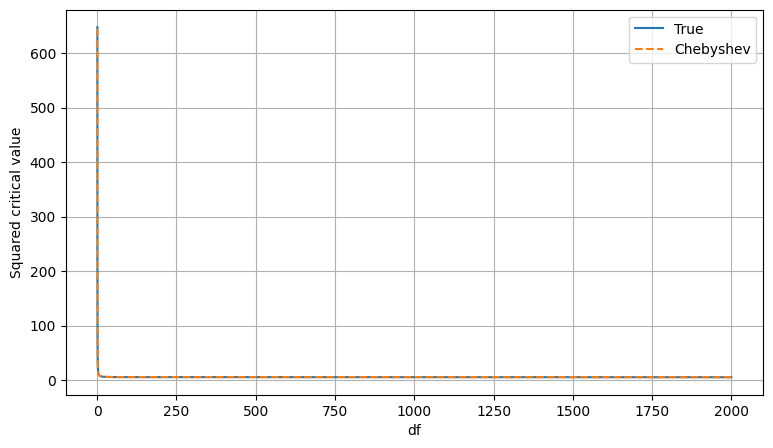

In [35]:
plt.figure(figsize=(9, 5))
plt.plot(df, y_true, label="True")
plt.plot(df, y_approx, "--", label="Chebyshev")
plt.xlabel("df")
plt.ylabel("Squared critical value")
plt.legend()
plt.grid(True)
plt.show()

## 4-1. t critical-value coefficients on InvDF in [1/2000, 1] (targets t and t^2)

`HEHypothesisTesting` maps InvDF = 1/df from [1/2000, 1] (df in [1, 2000]) to [-1, 1].
Coefficients for the two-sided critical value t_{1-alpha/2, df} (`_T_CRITICAL_COEFFS`) and its square
(`_T_CRITICAL_SQ_COEFFS`) are generated for degrees 2^3-1, ..., 2^7-1 and several alpha values.
Saved to `coeffs/t_critical_coeffs.py`.

In [7]:
from pathlib import Path
from numpy.polynomial import Chebyshev
from scipy import stats as sp_stats

T_ALPHA_LIST = [0.01, 0.025, 0.05, 0.1, 0.2]  # two-sided
T_LOG_DEG_LIST = range(3, 8)                  # degree = 2^3-1, ..., 2^7-1
T_U_MIN, T_U_MAX = 1.0 / 2000.0, 1.0

def make_t_target(alpha, power):
    def f(z):
        u = (T_U_MAX - T_U_MIN) * z / 2.0 + (T_U_MAX + T_U_MIN) / 2.0
        return sp_stats.t.ppf(1.0 - alpha / 2.0, 1.0 / u) ** power
    return f

# t_polys[power][degree][alpha], power 1: t, power 2: t^2
t_polys = {
    power: {
        2**ld-1: {
            alpha: Chebyshev.interpolate(make_t_target(alpha, power), 2**ld-1, domain=[-1.0, 1.0])
            for alpha in T_ALPHA_LIST
        }
        for ld in T_LOG_DEG_LIST
    }
    for power in (1, 2)
}

df_grid = np.geomspace(1.0, 2000.0, 20001)
z_grid = 2.0 * (1.0 / df_grid - T_U_MIN) / (T_U_MAX - T_U_MIN) - 1.0

print("target\tdegree\talpha\tMaxAE\t\tMaxRE")

for power, by_deg in t_polys.items():
    for deg, by_alpha in by_deg.items():
        for alpha, poly in by_alpha.items():
            y_true = sp_stats.t.ppf(1.0 - alpha / 2.0, df_grid) ** power
            err = np.abs(poly(z_grid) - y_true)
            print(f"{'t' if power == 1 else 't^2'}\t{deg}\t{alpha}\t{np.max(err):.2e}\t{np.max(err / y_true):.2e}")

t_coeff_path = Path("t_critical_coeffs.py")

lines = [
    "# Generated by coeffs/approx.ipynb (section 4-1)",
    "# Chebyshev coefficients of the two-sided t critical value (and its square)",
    "# as a function of InvDF = 1/df in [_T_CRITICAL_U_MIN, _T_CRITICAL_U_MAX], mapped to [-1, 1].",
    f"_T_CRITICAL_U_MIN = {T_U_MIN!r}",
    f"_T_CRITICAL_U_MAX = {T_U_MAX!r}",
    "",
]

for name, power in (("_T_CRITICAL_COEFFS", 1), ("_T_CRITICAL_SQ_COEFFS", 2)):
    lines.append(f"{name} = {{")
    for deg, by_alpha in t_polys[power].items():
        lines.append(f"    {deg}: {{")
        for alpha, poly in by_alpha.items():
            coeffs = ", ".join(repr(value) for value in poly.coef.astype(float).tolist())
            lines.append(f"        {alpha!r}: [{coeffs}],")
        lines.append("    },")
    lines.append("}")
    lines.append("")

_ = t_coeff_path.write_text("\n".join(lines), encoding="utf-8")
print(t_coeff_path.resolve())

target	degree	alpha	MaxAE		MaxRE


t	7	0.01	8.23e-04	1.97e-04
t	7	0.025	7.22e-05	2.12e-05
t	7	0.05	7.75e-06	2.60e-06
t	7	0.1	2.56e-07	4.10e-08
t	7	0.2	3.17e-07	2.41e-07
t	15	0.01	1.45e-07	3.60e-09
t	15	0.025	9.42e-08	4.90e-09
t	15	0.05	1.17e-08	4.65e-09
t	15	0.1	9.19e-09	5.41e-09


t	15	0.2	5.01e-09	3.81e-09


t	31	0.01	1.86e-07	4.96e-09
t	31	0.025	8.68e-08	4.23e-09
t	31	0.05	8.41e-09	4.16e-09
t	31	0.1	1.24e-08	7.32e-09
t	31	0.2	7.62e-09	4.67e-09
t	63	0.01	1.29e-07	4.32e-09
t	63	0.025	1.03e-07	4.90e-09
t	63	0.05	1.01e-08	4.97e-09
t	63	0.1	1.00e-08	4.86e-09


t	63	0.2	7.68e-09	5.84e-09


...

t^2	7	0.2	4.70e-06	1.95e-06


t^2	15	0.01	1.43e-05	1.37e-07
t^2	15	0.025	3.95e-06	9.77e-09
t^2	15	0.05	5.89e-08	9.29e-09
t^2	15	0.1	3.35e-08	1.09e-08
t^2	15	0.2	1.33e-08	7.59e-09
t^2	31	0.01	1.54e-05	1.55e-08
t^2	31	0.025	3.56e-06	9.81e-09
t^2	31	0.05	3.69e-08	8.34e-09
t^2	31	0.1	4.23e-08	1.47e-08


t^2	31	0.2	2.49e-08	9.36e-09


t^2	63	0.01	1.44e-05	1.25e-08
t^2	63	0.025	4.29e-06	1.03e-08
t^2	63	0.05	4.26e-08	9.94e-09
t^2	63	0.1	4.28e-08	9.70e-09
t^2	63	0.2	2.02e-08	1.17e-08
t^2	127	0.01	1.08e-05	1.11e-08
t^2	127	0.025	2.27e-06	9.62e-09
t^2	127	0.05	5.31e-08	8.38e-09
t^2	127	0.1	4.18e-08	1.46e-08


t^2	127	0.2	2.25e-08	1.13e-08
/pp_test/coeffs/t_critical_coeffs.py


## 5. Sign approximation (HEApprox.sign) check

Composite polynomial `coeffs/sign_coeffs.py` (StepHE, input in [-1, 1]).
Plaintext: error |P(x) - sign(x)| by |x| range and the valid range. HE: `HEApprox.sign` on a fresh
level-12 ciphertext, `SIGN_REPS` repetitions (time, bootstraps, output level, error by |x| range).

In [3]:
import matplotlib.pyplot as plt
from numpy.polynomial import chebyshev as np_cheb
from coeffs.sign_coeffs import _SIGN_PPTEST_DATA

sign_degrees = [len(c) - 1 for c in _SIGN_PPTEST_DATA]
print("stages:", len(sign_degrees), "degrees:", sign_degrees,
      "total depth:", sum(int(np.ceil(np.log2(d + 1))) for d in sign_degrees))

def sign_plain(x, return_stages=False):
    y, stages = np.asarray(x, dtype=np.float64), []
    for c in _SIGN_PPTEST_DATA:
        y = np_cheb.chebval(y, c)
        stages.append(y)
    return (y, stages) if return_stages else y

SIGN_BINS = [(10.0**-(k+1), 10.0**-k) for k in range(7)]  # [1e-1, 1), ..., [1e-7, 1e-6)

def sign_bin_errors(x, y):
    err = np.abs(y - np.sign(x))
    return {lo: float(np.max(err[(np.abs(x) >= lo) & (np.abs(x) < hi)])) for lo, hi in SIGN_BINS}

x_plain = np.concatenate([np.geomspace(1e-7, 1.0, 400001), -np.geomspace(1e-7, 1.0, 400001)])
y_plain, stages = sign_plain(x_plain, return_stages=True)

print("\nplaintext max |P(x) - sign(x)| by |x| range")
for lo, e in sign_bin_errors(x_plain, y_plain).items():
    print(f"  |x| in [{lo:.0e}, {lo*10:.0e}) : {e:.2e}")

print("\nmax |stage output| (regular bootstrap needs [-1, 1]):",
      [f"{np.max(np.abs(s)):.6f}" for s in stages])
print("first stage at x = 1:", np_cheb.chebval(1.0, _SIGN_PPTEST_DATA[0]))

stages: 8 degrees: [7, 7, 15, 15, 15, 15, 31, 31] total depth: 32



plaintext max |P(x) - sign(x)| by |x| range
  |x| in [1e-01, 1e+00) : 1.25e-09
  |x| in [1e-02, 1e-01) : 1.24e-09
  |x| in [1e-03, 1e-02) : 1.24e-09
  |x| in [1e-04, 1e-03) : 1.24e-09
  |x| in [1e-05, 1e-04) : 1.24e-09
  |x| in [1e-06, 1e-05) : 1.24e-09
  |x| in [1e-07, 1e-06) : 8.20e-10

max |stage output| (regular bootstrap needs [-1, 1]): ['1.000000', '1.000000', '1.000000', '1.000000', '1.000000', '1.000000', '1.000336', '1.000000']
first stage at x = 1: 1.7673630781089855e-07


In [4]:
import importlib
import operators.HEapprox
importlib.reload(operators.HEapprox)
from operators.HEapprox import HEApprox

approx = HEApprox(engine)

SIGN_REPS = 10

half = engine.num_slots // 2
x_sign = np.concatenate([np.geomspace(1e-7, 1.0, half), -np.geomspace(1e-7, 1.0, half)])

sign_runs = []

for rep in range(SIGN_REPS):
    ctxt = engine.enc(Message(x_sign, engine.log_slots), level=12)

    approx.reset_bootstrap_count()
    start = time.perf_counter()
    ret_ctxt = approx.sign(ctxt)
    elapsed = time.perf_counter() - start

    y_he = np.array(engine.dec(ret_ctxt)[0], dtype=np.complex128).real[:len(x_sign)]
    sign_runs.append({
        "time": elapsed,
        "bootstraps": approx.bootstrap_count(),
        "level": ret_ctxt.level(),
        "bins": sign_bin_errors(x_sign, y_he),
        "y": y_he,
    })

times = np.array([r["time"] for r in sign_runs])
print(f"time\t\t: {times.mean():.3f} +- {times.std(ddof=1):.3f} s ({SIGN_REPS} reps)")
print(f"bootstraps\t: {sorted(set(r['bootstraps'] for r in sign_runs))}")
print(f"output level\t: {sorted(set(r['level'] for r in sign_runs))}")

y_plain_he_input = sign_plain(x_sign)
print("\nmax |HE - sign(x)| (max over reps) | max |HE - plaintext P(x)| by |x| range")
for lo, hi in SIGN_BINS:
    mask = (np.abs(x_sign) >= lo) & (np.abs(x_sign) < hi)
    e_sign = max(r["bins"][lo] for r in sign_runs)
    e_plain = max(float(np.max(np.abs(r["y"][mask] - y_plain_he_input[mask]))) for r in sign_runs)
    print(f"  |x| in [{lo:.0e}, {hi:.0e}) : {e_sign:.2e} | {e_plain:.2e}")

near_one = np.abs(x_sign) > 0.99
print(f"\n|x| > 0.99: max |HE - sign(x)| = {max(np.max(np.abs(r['y'][near_one] - np.sign(x_sign[near_one]))) for r in sign_runs):.2e}")
wrong = [int(np.sum(np.sign(r["y"]) != np.sign(x_sign))) for r in sign_runs]
print(f"wrong-sign slots per rep: {wrong}")

time		: 10.504 +- 0.613 s (10 reps)
bootstraps	: [4]
output level	: [7]

max |HE - sign(x)| (max over reps) | max |HE - plaintext P(x)| by |x| range
  |x| in [1e-01, 1e+00) : 5.50e-09 | 5.90e-09
  |x| in [1e-02, 1e-01) : 7.37e-09 | 6.93e-09
  |x| in [1e-03, 1e-02) : 5.30e-09 | 6.06e-09
  |x| in [1e-04, 1e-03) : 6.06e-09 | 5.57e-09
  |x| in [1e-05, 1e-04) : 7.53e-09 | 8.00e-09
  |x| in [1e-06, 1e-05) : 6.79e-09 | 6.04e-09
  |x| in [1e-07, 1e-06) : 2.00e+00 | 2.00e+00

|x| > 0.99: max |HE - sign(x)| = 2.00e+00
wrong-sign slots per rep: [0, 1, 1, 2, 1, 1, 1, 0, 0, 0]


In [5]:
# Edges of the valid input range in HE: |x| near 1 (first stage vanishes at x = 1)
# and |x| near 0 (CKKS noise), SIGN_REPS repetitions.
q = engine.num_slots // 4
x_hi = np.linspace(0.95, 1.0, q)
x_lo = np.geomspace(1e-8, 1e-5, q)
x_edge = np.concatenate([x_hi, -x_hi, x_lo, -x_lo])

print("first stage near 1:", {v: round(float(np_cheb.chebval(v, _SIGN_PPTEST_DATA[0])), 6) for v in [0.95, 0.99, 0.999, 0.9999, 1.0]})

wrong_hi, wrong_lo = [], []

for rep in range(SIGN_REPS):
    ret_ctxt = approx.sign(engine.enc(Message(x_edge, engine.log_slots), level=12))
    y_edge = np.array(engine.dec(ret_ctxt)[0], dtype=np.complex128).real[:len(x_edge)]
    wrong = np.sign(y_edge) != np.sign(x_edge)
    ax = np.abs(x_edge)
    wrong_hi.extend(ax[wrong & (ax > 0.5)])
    wrong_lo.extend(ax[wrong & (ax < 0.5)])

print(f"wrong-sign |x| in [0.95, 1]  : {len(wrong_hi)} slots over {SIGN_REPS} reps, smallest |x| = {min(wrong_hi) if wrong_hi else None}")
print(f"wrong-sign |x| in [1e-8, 1e-5]: {len(wrong_lo)} slots over {SIGN_REPS} reps, largest |x| = {max(wrong_lo) if wrong_lo else None}")

first stage near 1: {0.95: 0.817549, 0.99: 0.232561, 0.999: 0.025068, 0.9999: 0.002526, 1.0: 0.0}


wrong-sign |x| in [0.95, 1]  : 9 slots over 10 reps, smallest |x| = 1.0
wrong-sign |x| in [1e-8, 1e-5]: 5652 slots over 10 reps, largest |x| = 1.4697949308248822e-07


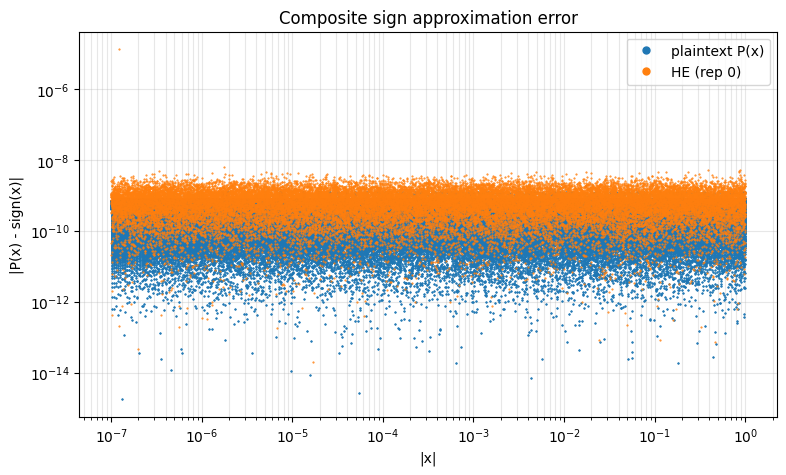

In [6]:
plt.figure(figsize=(9, 5))
plt.loglog(np.abs(x_plain), np.abs(y_plain - np.sign(x_plain)) + 1e-17, ".", ms=1, label="plaintext P(x)")
plt.loglog(np.abs(x_sign), np.abs(sign_runs[0]["y"] - np.sign(x_sign)) + 1e-17, ".", ms=1, label="HE (rep 0)")
plt.xlabel("|x|")
plt.ylabel("|P(x) - sign(x)|")
plt.title("Composite sign approximation error")
plt.legend(markerscale=10)
plt.grid(True, which="both", alpha=0.3)
plt.show()